<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/week1_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 - PCA From Scratch
**Goal:** Implement PCA using only NumPy and verify it matches sklearn.

### The 4 Steps of PCA
1. Mean-center X
2. Compute the covariance matrix
3. Get eigenvectors via `np.linalg.eigh`, sort descending
4. Project X onto the top n eigenvectors

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

---
## Day 5 - Steps 1 & 2: Mean-Centering and Covariance Matrix
---

### Step 1 - Create data and mean-center it
Mean-centering shifts the data so each feature has a mean of 0.
This is required before computing the covariance matrix.

In [2]:
np.random.seed(24) # Fav Number
X = np.random.rand(100, 3)

print("Original X shape:", X.shape)
print("First 5 rows:")
print(X[:5])

Original X shape: (100, 3)
First 5 rows:
[[0.9600173  0.69951205 0.99986729]
 [0.2200673  0.36105635 0.73984099]
 [0.99645573 0.31634698 0.13654458]
 [0.38398001 0.32051928 0.36641475]
 [0.70965156 0.90014243 0.53411544]]


In [3]:
# Mean-center using broadcasting (from earlier this week)
means = np.mean(X, axis=0)          # shape (3,) — one mean per column
X_centered = X - means              # broadcast subtracts mean from every row

print("X_centered shape:", X_centered.shape)
print("Column means after centering:", np.round(np.mean(X_centered, axis=0), 10))
print("Verification (all ~0):", np.allclose(np.mean(X_centered, axis=0), 0))

X_centered shape: (100, 3)
Column means after centering: [ 0.  0. -0.]
Verification (all ~0): True


### Step 2 - Compute the covariance matrix

The covariance matrix is always shape **(n_features × n_features)** — here (3×3).

- **Diagonal values** = variance of each individual feature (how spread out it is)
- **Off-diagonal values** = covariance between pairs of features (how much they move together)

Note: `np.cov` expects features as rows, so we pass `X_centered.T`.

In [4]:
cov = np.cov(X_centered.T)   # shape (3, 3)

print("Covariance matrix shape:", cov.shape)
print("\nCovariance matrix:")
print(cov)
print("\nDiagonal (variances per feature):", np.diag(cov))
print("Is symmetric:", np.allclose(cov, cov.T))

Covariance matrix shape: (3, 3)

Covariance matrix:
[[ 0.10134246  0.00594307 -0.00657217]
 [ 0.00594307  0.08071452 -0.00510024]
 [-0.00657217 -0.00510024  0.0933365 ]]

Diagonal (variances per feature): [0.10134246 0.08071452 0.0933365 ]
Is symmetric: True


### Exploring covariance with correlated features

When features are correlated (y = 2x + noise), the off-diagonal values become large.
This is PCA's signal — "these features move together, I can collapse them into one direction."

In [5]:
np.random.seed(24)
x_feat = np.random.randn(100)
y_feat = 2 * x_feat + np.random.randn(100) * 0.3

# Stack as columns so shape is (100, 2) — samples × features
X_corr = np.column_stack((x_feat, y_feat))
print("Correlated X shape:", X_corr.shape)

cov_corr = np.cov(X_corr.T)
print("\nCovariance matrix (correlated features):")
print(cov_corr)
print("\nOff-diagonal values are large — features strongly co-vary.")

# Compare to uncorrelated
X_uncorr = np.random.randn(100, 2)
cov_uncorr = np.cov(X_uncorr.T)
print("\nCovariance matrix (uncorrelated features):")
print(cov_uncorr)
print("\nOff-diagonal values are near 0 — features don't co-vary.")

Correlated X shape: (100, 2)

Covariance matrix (correlated features):
[[1.08093686 2.20479546]
 [2.20479546 4.57526628]]

Off-diagonal values are large — features strongly co-vary.

Covariance matrix (uncorrelated features):
[[ 0.89971888 -0.08600287]
 [-0.08600287  0.94431757]]

Off-diagonal values are near 0 — features don't co-vary.


**What does the covariance matrix tell you that the mean doesn't?**

| | Mean Vector | Covariance Matrix |
|---|---|---|
| **Answers** | Where is the data centered? | How do features relate to each other? |
| **Diagonal** | Average of each feature | Variance of each feature |
| **Off-diagonal** | — | Covariance between feature pairs |
| **Visualized as** | A single point | An ellipse or ellipsoid |

---

---
## Day 6 - Steps 3 & 4: Eigenvectors and Projection
---

### Step 3 - Get eigenvectors, sort descending

We use `np.linalg.eigh` (not `eig`) because:
- Our covariance matrix is always **symmetric**
- `eigh` guarantees **real** eigenvalues and is more numerically stable
- `eigh` returns eigenvalues in **ascending** order — we sort descending so PC1 (most variance) comes first

In [6]:
# Work with the original (100x3) X from Step 1
evals, evecs = np.linalg.eigh(cov)   # cov is (3x3), so evals shape (3,), evecs shape (3,3)

print("Eigenvalues (ascending):", evals)
print("Eigenvectors shape:", evecs.shape)

# Sort descending — most important component first
sorted_idx = np.argsort(evals)[::-1]
evals_desc = evals[sorted_idx]
evecs_desc = evecs[:, sorted_idx]    # columns are eigenvectors — sort columns

print("\nEigenvalues (descending):", evals_desc)
print("Eigenvectors (descending):")
print(evecs_desc)

Eigenvalues (ascending): [0.07830067 0.08982576 0.10726705]
Eigenvectors shape: (3, 3)

Eigenvalues (descending): [0.10726705 0.08982576 0.07830067]
Eigenvectors (descending):
[[-0.82502348 -0.53715715 -0.17549487]
 [-0.27904717  0.1172034   0.95309813]
 [ 0.49139488 -0.83529968  0.24658774]]


### Step 4 - Project X onto the top n eigenvectors

Projection = dot product of centered data with eigenvectors.

- `X_centered` shape: (100, 3)
- `top_evecs` shape: (3, n_components)
- Result shape: (100, n_components)

Each row is a data point in the new PCA space. Each column is a principal component.

In [7]:
n_components = 2
top_evecs = evecs_desc[:, :n_components]   # shape (3, 2) — top 2 eigenvectors

# Project: each data point gets new coordinates in PCA space
X_projected = np.dot(X_centered, top_evecs)       # (100,3) @ (3,2) = (100,2)

print("X_centered shape:", X_centered.shape)
print("top_evecs shape:", top_evecs.shape)
print("X_projected shape:", X_projected.shape)

X_centered shape: (100, 3)
top_evecs shape: (3, 2)
X_projected shape: (100, 2)


### Wrap all 4 steps into a clean function

In [8]:
def my_pca(X, n_components):
    """
    PCA from scratch using only NumPy.

    Steps:
    1. Mean-center X
    2. Compute covariance matrix
    3. Get eigenvectors via eigh, sort descending
    4. Project X onto top n eigenvectors
    """
    # Step 1: Mean-center
    X_centered = X - np.mean(X, axis=0)

    # Step 2: Covariance matrix
    cov = np.cov(X_centered.T)

    # Step 3: Eigenvectors, sorted descending
    evals, evecs = np.linalg.eigh(cov)
    sorted_idx = np.argsort(evals)[::-1]
    evecs = evecs[:, sorted_idx]
    evals = evals[sorted_idx]

    # Step 4: Project
    top_evecs = evecs[:, :n_components]
    X_projected = X_centered @ top_evecs

    # Also return explained variance ratio
    explained_variance_ratio = evals / evals.sum()

    return X_projected, explained_variance_ratio


# Test it
np.random.seed(123)
X = np.random.rand(100, 3)

X_my, evr_my = my_pca(X, n_components=2)
print("my_pca output shape:", X_my.shape)
print("Explained variance ratio:", evr_my)

my_pca output shape: (100, 2)
Explained variance ratio: [0.38479764 0.32697194 0.28823041]


---
## Verification - my_pca vs sklearn

sklearn's PCA uses SVD internally (more numerically stable than eigendecomposition).
Results should match up to **sign flips** — eigenvectors can point in either direction
and still be mathematically correct. We compare absolute values to handle this.

---

In [9]:
# sklearn PCA on the same data
sklearn_pca = PCA(n_components=2)
X_sklearn = sklearn_pca.fit_transform(X)

print("my_pca output shape:", X_my.shape)
print("sklearn output shape:", X_sklearn.shape)

# Compare — use absolute values to handle sign flips
match = np.allclose(np.abs(X_my), np.abs(X_sklearn))
print("\nOutputs match (up to sign flips):", match)

# Show first 5 rows of each
print("\nmy_pca (first 5 rows):")
print(X_my[:5])
print("\nsklearn (first 5 rows):")
print(X_sklearn[:5])

my_pca output shape: (100, 2)
sklearn output shape: (100, 2)

Outputs match (up to sign flips): True

my_pca (first 5 rows):
[[-0.387066    0.09057936]
 [-0.05849199 -0.08864876]
 [-0.2277439   0.27511091]
 [ 0.19887403  0.10889834]
 [-0.1635364   0.0822198 ]]

sklearn (first 5 rows):
[[-0.387066    0.09057936]
 [-0.05849199 -0.08864876]
 [-0.2277439   0.27511091]
 [ 0.19887403  0.10889834]
 [-0.1635364   0.0822198 ]]


In [10]:
# Compare explained variance ratios
print("my_pca explained variance ratio:   ", np.round(evr_my[:2], 6))
print("sklearn explained variance ratio:  ", np.round(sklearn_pca.explained_variance_ratio_, 6))
print("Match:", np.allclose(evr_my[:2], sklearn_pca.explained_variance_ratio_))

my_pca explained variance ratio:    [0.384798 0.326972]
sklearn explained variance ratio:   [0.384798 0.326972]
Match: True


**Why sign flips happen:**
An eigenvector v and -v are both valid — they point in opposite directions along the same axis.
sklearn normalizes its sign convention; ours may differ. The data they represent is identical.
This is why we compare `np.abs(mine)` vs `np.abs(sklearn)` rather than the raw values.

---

---
## Explained Variance - How many components do we need?
---

Explained variance per component:
  PC1: 38.5%  (cumulative: 38.5%)
  PC2: 32.7%  (cumulative: 71.2%)
  PC3: 28.8%  (cumulative: 100.0%)


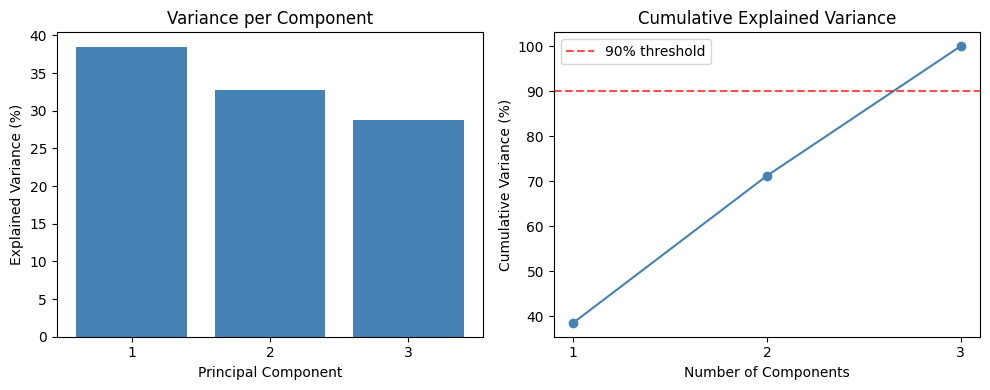

In [11]:
# Run full PCA (all 3 components) to see all variance ratios
_, evr_full = my_pca(X, n_components=3)

cumulative = np.cumsum(evr_full)

print("Explained variance per component:")
for i, (evr, cum) in enumerate(zip(evr_full, cumulative)):
    print(f"  PC{i+1}: {evr*100:.1f}%  (cumulative: {cum*100:.1f}%)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(range(1, 4), evr_full * 100, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Variance per Component')
ax1.set_xticks(range(1, 4))

ax2.plot(range(1, 4), cumulative * 100, marker='o', color='steelblue')
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xticks(range(1, 4))
ax2.legend()

plt.tight_layout()
plt.show()

---
## Summary - What I built

| Step | Code | Purpose |
|---|---|---|
| 1. Mean-center | `X - np.mean(X, axis=0)` | Remove location, keep shape |
| 2. Covariance | `np.cov(X_centered.T)` | Capture feature relationships |
| 3. Eigenvectors | `np.linalg.eigh(cov)` | Find directions of max variance |
| 4. Project | `X_centered @ top_evecs` | Express data in new PCA space |

**Key insight:** PCA finds the directions (eigenvectors) in which your data varies the most (largest eigenvalues), then projects your data onto those directions. The result is a lower-dimensional representation that preserves as much information as possible.

**Next Week:** Run this on MNIST (784 dimensions → 2D) and visualize digit clusters.